In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
# Load the main.config.json file 

def load_main_config():
    with open("../config/main.config.json", "r") as f:
        return json.load(f)

main_config = load_main_config()
main_config

{'active_version': 'v2',
 'paths': {'model': 'models/v2/model_bundle.pkl',
  'thresholds': 'config/v2/threshold-config.json',
  'data_config': 'config/v2/data-config.json'},
 'data': {'filename': 'synthetic_ecomops_logs.csv'},
 's3': {'bucket': 'e-com-sla', 'prefix': 'anomaly-detection'},
 'flags': {'upload_to_s3': False, 'download_from_s3': False}}

In [3]:
def get_path(key, config):
    return "../" + config["paths"][key]

data_config_path = get_path("data_config", main_config)

with open(data_config_path, "r") as f:
    data_config = json.load(f)

data_config.keys()

dict_keys(['_meta', 'noise', 'system_dynamics', 'traffic_curve', 'operations', 'hourly_rules', 'anomaly_injection'])

In [4]:
np.random.seed(42)

def add_noise(value, pct):
    return value * (1 + np.random.uniform(-pct, pct))

def random_in_range(low, high, pct):
    base = np.random.uniform(low, high)
    return add_noise(base, pct)

def compute_hour_factor(hour, config):
    curve = config["traffic_curve"]

    base = curve["base"]

    # Evening peak (circular)
    ep = curve["evening_peak"]
    d = min(abs(hour - ep["center"]), 24 - abs(hour - ep["center"]))
    evening = ep["amplitude"] * np.exp(-(d**2) / ep["spread"])

    # Midday peak
    mp = curve["midday_peak"]
    midday = mp["amplitude"] * np.exp(-((hour - mp["center"])**2) / mp["spread"])

    # Early dip
    ed = curve["early_dip"]
    dip = ed["amplitude"] * np.exp(-((hour - ed["center"])**2) / ed["spread"])

    return base + evening + midday - dip

def apply_hourly_rules(cmd, hour, values, hourly_rules):
    hour_str = str(hour)

    if hour_str in hourly_rules and cmd in hourly_rules[hour_str]:
        rules = hourly_rules[hour_str][cmd]

        for key, multiplier in rules.items():
            field = key.replace("_multiplier", "")

            # 🚨 ONLY allow latency + failure rules
            if field in ["success_rt_avg", "fail_rt_avg", "fail_vol"]:
                if field in values:
                    values[field] *= multiplier

    return values

def apply_load_dynamics(op, values, cfg, config):
    """
    Apply realistic system load behavior:
    Volume → Latency → Failures
    """

    baseline_vol = cfg["success_vol"]

    if baseline_vol <= 0:
        return values

    # ----------------------------
    # 1. Compute load
    # ----------------------------
    load_factor = values["success_vol"] / baseline_vol
    load_delta = load_factor - 1

    # Clamp extreme spikes
    load_delta = min(load_delta, 3)

    latency_factor = config["system_dynamics"]["latency_increase_factor"]
    failure_factor = config["system_dynamics"]["failure_increase_factor"]

    # ----------------------------
    # 2. Apply effects
    # ----------------------------

    # Latency increases with load
    values["success_rt_avg"] *= (1 + latency_factor * load_delta)
    values["fail_rt_avg"] *= (1 + latency_factor * load_delta)

    # Failures increase more aggressively non linearly
    values["fail_vol"] *= (1 + failure_factor * (load_factor ** 1.3 - 1))

    # ----------------------------
    # 3. Safety clamps
    # ----------------------------
    values["success_rt_avg"] = max(values["success_rt_avg"], 1)
    values["fail_rt_avg"] = max(values["fail_rt_avg"], 1)
    values["fail_vol"] = max(values["fail_vol"], 0)

    return values

In [5]:
def inject_anomaly(values):

    metric = np.random.choice([
        "success_vol",
        "fail_vol",
        "success_rt",
        "fail_rt"
    ])

    # =========================
    # 🔥 1. LATENCY (RT)
    # =========================
    if metric in ["success_rt", "fail_rt"]:

        # ONLY increase latency
        factor = np.random.uniform(2, 6)
        values[metric] *= factor

        return values, f"{metric}_spike"


    # =========================
    # 🔥 2. SUCCESS VOLUME
    # =========================
    elif metric == "success_vol":

        direction = np.random.choice(["up", "down"])

        if direction == "up":
            factor = np.random.uniform(2, 5)   # spike
        else:
            factor = np.random.uniform(0.1, 0.6)  # drop

        values[metric] *= factor

        return values, f"{metric}_{direction}"


    # =========================
    # 🔥 3. FAILURE VOLUME
    # =========================
    elif metric == "fail_vol":

        # ONLY increase failures (important)
        factor = np.random.uniform(2, 8)
        values[metric] *= factor

        return values, f"{metric}_spike"

In [6]:
def inject_anomaly(values, config):

    anomaly_cfg = config["anomaly_injection"]
    rules = anomaly_cfg["rules"]

    # pick anomaly type (not metric anymore)
    anomaly_type = np.random.choice(list(rules.keys()))
    rule = rules[anomaly_type]

    targets = rule["targets"]
    factor_min, factor_max = rule["factor_range"]

    factor = np.random.uniform(factor_min, factor_max)

    # ----------------------------
    # 🔥 APPLY ANOMALY
    # ----------------------------
    for t in targets:

        # map config names → actual keys
        if t == "success_rt":
            key = "success_rt_avg"
        elif t == "fail_rt":
            key = "fail_rt_avg"
        else:
            key = t

        if key not in values:
            continue

        # ----------------------------
        # LATENCY (ONLY INCREASE)
        # ----------------------------
        if key in ["success_rt_avg", "fail_rt_avg"]:
            values[key] *= factor

        # ----------------------------
        # SUCCESS VOLUME
        # ----------------------------
        elif key == "success_vol":

            # traffic_drop rule
            if anomaly_type == "traffic_drop":
                values[key] *= factor  # factor < 1
            else:
                values[key] *= factor  # factor > 1

        # ----------------------------
        # FAILURE VOLUME
        # ----------------------------
        elif key == "fail_vol":
            values[key] *= factor

    return values, anomaly_type

In [7]:
def generate_test_data(start_date, hours, config, anomaly_prob=0.2):

    RANDOMNESS = config["randomness"]
    commands_config = config["commands"]
    hourly_rules = config["hourly_rules"]

    data = []
    current = start_date

    for _ in range(hours):
        hour = current.hour

        for cmd, cfg in commands_config.items():

            values = {
                "success_vol": add_noise(cfg["success_vol"], RANDOMNESS*2),
                "fail_vol": add_noise(cfg["fail_vol"], RANDOMNESS*3),
                "success_rt": random_in_range(*cfg["success_rt"], RANDOMNESS),
                "fail_rt": random_in_range(*cfg["fail_rt"], RANDOMNESS)
            }

            values = apply_hourly_rules(cmd, hour, values, hourly_rules)

            is_anomaly = False
            anomaly_type = "normal"

            if np.random.rand() < anomaly_prob:
                values, anomaly_type = inject_anomaly(values)
                is_anomaly = True

            data.append({
                "timestamp": current,
                "operation": cmd,   # changed from command → operation
                "success_vol": int(values["success_vol"]),
                "success_rt_avg": round(values["success_rt"], 3),
                "fail_vol": int(values["fail_vol"]),
                "fail_rt_avg": round(values["fail_rt"], 3),
                "is_anomaly": is_anomaly,
                "anomaly_type": anomaly_type
            })

        current += timedelta(hours=1)

    return pd.DataFrame(data)

In [8]:
def generate_test_data2(start_date, hours, config):

    RANDOMNESS = config["noise"]
    operations_config = config["operations"]
    hourly_rules = config["hourly_rules"]

    data = []
    current = start_date

    for _ in range(hours):
        hour = current.hour

        hour_factor = compute_hour_factor(hour, config)

        for op, cfg in operations_config.items():

            base_vol = cfg["success_vol"]

            # ----------------------------
            # 1. TRAFFIC (CURVE-BASED)
            # ----------------------------
            success_vol = base_vol * hour_factor
            
            # ----------------------------
            # 2. ADD NOISE
            # ----------------------------
            values = {
                "success_vol": add_noise(success_vol, RANDOMNESS["success_vol_std_pct"]),
                "fail_vol": add_noise(cfg["fail_vol"], RANDOMNESS["fail_vol_std_pct"]),
                "success_rt_avg": random_in_range(*cfg["success_rt_avg"], RANDOMNESS["latency_std_pct"]),
                "fail_rt_avg": random_in_range(*cfg["fail_rt_avg"], RANDOMNESS["latency_std_pct"])
            }
            
            # ----------------------------
            # 3. LOAD DYNAMICS
            # ----------------------------
            values = apply_load_dynamics(op, values, cfg, config)

            # ----------------------------
            # 4. HOURLY RULES (EXCEPTIONS ONLY)
            # ----------------------------
            values = apply_hourly_rules(op, hour, values, hourly_rules)

            is_anomaly = False
            anomaly_type = "normal"

            if np.random.rand() < config["anomaly_injection"]["probability"]:
                values, anomaly_type = inject_anomaly(values, config)
                is_anomaly = True

            # ----------------------------
            # 5. FINAL OUTPUT
            # ----------------------------
            data.append({
                "timestamp": current,
                "operation": op,
                "success_vol": int(values["success_vol"]),
                "success_rt_avg": round(values["success_rt_avg"], 3),
                "fail_vol": int(values["fail_vol"]),
                "fail_rt_avg": round(values["fail_rt_avg"], 3),
                "is_anomaly": is_anomaly,
                "anomaly_type": anomaly_type
            })

        current += timedelta(hours=1)

    return pd.DataFrame(data)

In [9]:
df_test = generate_test_data2(
    start_date=datetime(2025, 1, 1),
    hours=48,   # start with 1 week
    config=data_config
)

df_test.head()

,timestamp,operation,success_vol,success_rt_avg,fail_vol,fail_rt_avg,is_anomaly,anomaly_type
0,2025-01-01,browse_products,121586,44.273,1273,5.404,True,cascade_failure
1,2025-01-01,view_cart,34666,43.810,335,11.882,False,normal
2,2025-01-01,add_to_cart,19664,54.610,600,35.411,False,normal
3,2025-01-01,checkout,5687,205.293,295,134.243,True,traffic_drop
4,2025-01-01,payment,6273,395.776,194,144.487,False,normal


In [10]:
def prepare_features(df):
    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour
    
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    
    # one-hot encoding
    dummies = pd.get_dummies(df["operation"], prefix="operation")
    df = pd.concat([df, dummies], axis=1)
    
    return df

In [11]:
import joblib

bundle = joblib.load("../models/v2/model_bundle.pkl")

models = bundle["models"]
features = bundle["feature_map"]
targets = bundle["targets"]
thresholds = bundle["thresholds"]

In [29]:
def run_inference(df):

    df = prepare_features(df)
    results = []

    for _, row in df.iterrows():

        op = row["operation"]
        hour = row["hour"]

        success_vol = row["success_vol"]
        fail_vol = row["fail_vol"]
        success_rt_avg = row["success_rt_avg"]
        fail_rt_avg = row["fail_rt_avg"]
        is_anomaly = row["is_anomaly"]
        anomaly_type = row["anomaly_type"]

        is_anomaly = False
        max_severity = 0
        root_causes = []

        # 🔥 store predictions
        preds = {}

        for t in targets:

            feat = features[t]
            pred = models[t].predict([row[feat]])[0]
            actual = row[t]

            preds[f"pred_{t}"] = pred  # ✅ store prediction

            rule = thresholds[op][hour][t]

            threshold_val = max(
                pred * rule["percent_threshold"],
                rule["abs_threshold"]
            )

            deviation = 0

            # =========================
            # LATENCY
            # =========================
            if t in ["success_rt_avg", "fail_rt_avg"]:
                
                deviation = actual - pred
                threshold_val *= 1.2
                if deviation <= 0:
                    continue

            # =========================
            # SUCCESS VOLUME
            # =========================
            elif t == "success_vol":

                deviation = abs(actual - pred)
                threshold_val *= 1.2

            # =========================
            # FAILURE VOLUME
            # =========================
            elif t == "fail_vol":

                deviation = actual - pred
                threshold_val *= 1.2
                if deviation <= 0:
                    continue

            # =========================
            # ANOMALY CHECK
            # =========================
            if deviation > threshold_val:

                is_anomaly = True

                severity = deviation / (threshold_val + 1e-6)

                root_causes.append((t, severity))

                if severity > max_severity:
                    max_severity = severity

        root_causes = sorted(root_causes, key=lambda x: x[1], reverse=True)

        results.append({
            "operation": op,
            "hour": hour,
            "success_vol": success_vol,
            "fail_vol": fail_vol,
            "success_rt_avg": success_rt_avg,
            "fail_rt_avg": fail_rt_avg,

            # 🔥 add predictions
            **preds,

            "Status": "Anomaly 🚨" if is_anomaly else "Normal ✅",
            "Root_Cause": root_causes[0][0] if is_anomaly else None,
            "All_Causes": root_causes if is_anomaly else None,
            "Severity": round(max_severity, 3),
            "is_anomaly": is_anomaly,
            "anomaly_type": anomaly_type
        })

    return pd.DataFrame(results)

In [30]:
def evaluate(df, results_df):
    
    merged = results_df.copy()
    merged["actual"] = df["is_anomaly"].values
    
    total = len(merged)
    alerts = (merged["Status"] != "Normal ✅").sum()
    actual = merged["actual"].sum()
    
    tp = ((merged["Status"] != "Normal ✅") & merged["actual"]).sum()
    fp = ((merged["Status"] != "Normal ✅") & ~merged["actual"]).sum()
    fn = ((merged["Status"] == "Normal ✅") & merged["actual"]).sum()
    
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    alert_rate = alerts / total
    
    print("\n===== PERFORMANCE =====")
    print(f"Total: {total}")
    print(f"Actual Anomalies: {actual}")
    print(f"Detected Alerts: {alerts}")
    
    print(f"\nPrecision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"Alert Rate: {alert_rate:.3f}")

In [35]:
# 1. Generate data
df_test = generate_test_data2(start_date=datetime(2025, 1, 16), hours=96, config=data_config)

# 2. Run inference
results = run_inference(df_test)

# 3. Evaluate
evaluate(df_test, results)

# 4. View sample
print(results.head(30))


===== PERFORMANCE =====
Total: 480
Actual Anomalies: 35
Detected Alerts: 33

Precision: 0.939
Recall: 0.886
Alert Rate: 0.069
          operation  hour  success_vol  fail_vol  success_rt_avg  fail_rt_avg  \
0   browse_products     0       107184       388          13.238        8.429   
1         view_cart     0        80302       368          27.951       15.723   
2       add_to_cart     0        18599       648          46.926       43.904   
3          checkout     0         7345       279         184.468       83.944   
4           payment     0         7067       261         182.849      207.410   
5   browse_products     1        92714       428          23.367        8.266   
6         view_cart     1        25746       397          25.465       11.936   
7       add_to_cart     1        10985       644          62.209       42.937   
8          checkout     1         6314       235         185.937       87.952   
9           payment     1         5038       184         193.78

In [15]:
print(results)

           operation  hour  success_vol  fail_vol  success_rt_avg  \
0    browse_products     0       131310       449          13.507   
1          view_cart     0        31110       342          18.017   
2        add_to_cart     0        22342       689          48.162   
3           checkout     0         9722       381         228.509   
4            payment     0         6353       217         274.428   
..               ...   ...          ...       ...             ...   
475  browse_products    23       144320       545          11.129   
476        view_cart    23        36927       371          23.774   
477      add_to_cart    23        30460       859          75.329   
478         checkout    23        11728       353         182.653   
479          payment    23         8325       323         229.707   

     fail_rt_avg  pred_success_vol  pred_fail_vol  pred_success_rt_avg  \
0          9.235     115484.773438     519.759521            18.271439   
1         11.970      2

In [16]:
anomalies = results[results["Status"] == "Anomaly 🚨"]

for _, row in anomalies.iterrows():
    print(row)

operation                                       view_cart
hour                                                    2
success_vol                                         12034
fail_vol                                              354
success_rt_avg                                     16.896
fail_rt_avg                                        11.454
pred_success_vol                             18482.779297
pred_fail_vol                                  267.452515
pred_success_rt_avg                             22.123896
pred_fail_rt_avg                                12.546354
Status                                          Anomaly 🚨
Root_Cause                                    success_vol
All_Causes             [(success_vol, 1.052142412487506)]
Severity                                            1.052
is_anomaly                                           True
anomaly_type                                 traffic_drop
Name: 11, dtype: object
operation                                       

In [17]:
xdata = []
ydata = []

for hour in range (0 , 24):
    d = np.minimum(np.abs(hour - 20), 24 - np.abs(hour - 20))
    
    hour_factor = (
        0.5
        + 1.1 * np.exp(-(d**2) / 20)                 # evening peak (8–10 PM)
        + 1 * np.exp(-((hour - 13)**2) / 10)      # midday peak (1–2 PM)
        - 0.25 * np.exp(-((hour - 4)**2) / 6)        # early morning dip (4–5 AM)
    )

    print("Hour:",hour, " ,Factor:", hour_factor)
    xdata.append(hour)
    ydata.append(hour_factor)

print(xdata)
print(ydata)

Hour: 0  ,Factor: 0.976891043476631
Hour: 1  ,Factor: 0.759373293899471
Hour: 2  ,Factor: 0.5534800567988389
Hour: 3  ,Factor: 0.38334791385641653
Hour: 4  ,Factor: 0.2951419635142817
Hour: 5  ,Factor: 0.30920573815396335
Hour: 6  ,Factor: 0.38650404501177044
Hour: 7  ,Factor: 0.4741348306173243
Hour: 8  ,Factor: 0.5655353802074128
Hour: 9  ,Factor: 0.7006142028020422
Hour: 10  ,Factor: 0.9133617133954266
Hour: 11  ,Factor: 1.1894136673931064
Hour: 12  ,Factor: 1.4496700151368767
Hour: 13  ,Factor: 1.594922602409536
Hour: 14  ,Factor: 1.5866661806353335
Hour: 15  ,Factor: 1.4854753221456662
Hour: 16  ,Factor: 1.400831520260105
Hour: 17  ,Factor: 1.4032874847784598
Hour: 18  ,Factor: 1.4826888270096774
Hour: 19  ,Factor: 1.5736760893980781
Hour: 20  ,Factor: 1.6074465830709244
Hour: 21  ,Factor: 1.5480139242239594
Hour: 22  ,Factor: 1.400907367523859
Hour: 23  ,Factor: 1.2014363667137131
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
[np.float64(0

In [18]:
import matplotlib.pyplot as plt

In [19]:
pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from scipy.optimize import curve_fit

In [21]:
def model(hour, base, A1, sigma1, A2, sigma2, A3, sigma3):
    d = np.minimum(np.abs(hour - 20), 24 - np.abs(hour - 20))
    
    return (
        base
        + A1 * np.exp(-(d**2) / sigma1)            # evening peak
        + A2 * np.exp(-((hour - 13)**2) / sigma2)  # midday
        - A3 * np.exp(-((hour - 4)**2) / sigma3)   # early dip
    )

In [22]:
from scipy.optimize import curve_fit
import numpy as np

xdata = np.array(xdata)
ydata = np.array(ydata)

params, _ = curve_fit(
    model,
    xdata,
    ydata,
    p0=[0.5, 1.0, 20, 1.0, 10, 0.2, 6]  # initial guess
)

In [23]:
print(params)

[ 0.5   1.1  20.    1.   10.    0.25  6.  ]


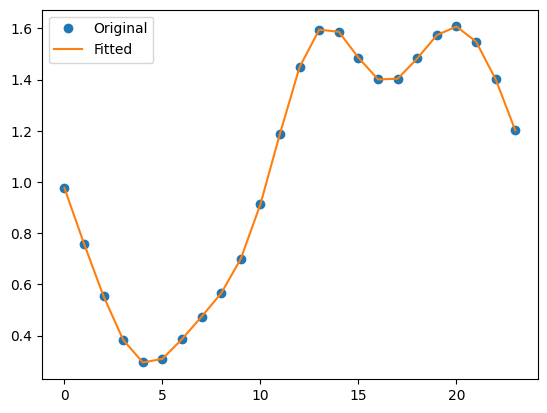

In [24]:
import matplotlib.pyplot as plt

hours = np.arange(24)
pred = model(hours, *params)

plt.plot(hours, ydata, 'o', label="Original")
plt.plot(hours, pred, '-', label="Fitted")
plt.legend()
plt.show()